<a href="https://colab.research.google.com/github/dai-fujiden/boite-a-jouets/blob/main/phono_chine/Zhongwen_yinjie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. Visit the website  Unicode https://home.unicode.org/

### 2. Unihan database explanation  https://www.unicode.org/reports/tr38/ . Reach the hyperlinked text, the UCD (the Unicode Character Database).


### 3. search the following texts using `ctrl+F` and click here.
```
Unihan Database
Latest version:
https://www.unicode.org/Public/UCD/latest/ucd/Unihan.zip
Version 17.0.0:
https://www.unicode.org/Public/17.0.0/ucd/Unihan.zip
```

### 4. Download frequency data
https://lingua.mtsu.edu/chinese-computing/statistics/index.html?utm_source=chatgpt.com


In [76]:
!pip install japanize-matplotlib
!pip install pykakasi

In [77]:
!git clone https://github.com/cmu-llab/wikihan.git

!git clone https://github.com/unicode-org/unihan-database.git

fatal: destination path 'wikihan' already exists and is not an empty directory.
fatal: destination path 'unihan-database' already exists and is not an empty directory.


In [78]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import japanize_matplotlib
japanize_matplotlib.japanize()
rows = []

with open("Unihan_Readings.txt", encoding="utf-8") as f:
    for line in f:
        # print(line)
        if line.startswith("#"):
            continue

        cols = line.strip().split("\t")
        # print(cols)
        if len(cols) != 3:
            continue

        code, field, value = cols

        if field != "kMandarin":
            continue

        cp = int(code[2:], 16)
        hanzi = chr(cp)

        for pinyin in value.split():
            rows.append([hanzi, pinyin])

df = pd.DataFrame(rows, columns=["漢字", "ピンイン"])

df.to_csv("unihan_pinyin.csv", index=False, encoding="utf-8-sig")

In [79]:
df_freq = pd.read_excel("/content/CharFreq-Imaginative.xls").iloc[:,1:-2]
df_freq

,汉字,频率,累计频率(%)
0,的,3244537,3.718684
1,一,1646186,5.605439
2,了,1380375,7.187538
3,是,1327443,8.708969
4,不,1285160,10.181939
...,...,...,...
8430,鴫,1,99.999995
8431,鴰,1,99.999997
8432,鹹,1,99.999998
8433,麅,1,99.999999


In [80]:
df_freq = df_freq.rename(columns= {"汉字":"漢字"})
df = pd.merge(df, df_freq, how = "inner")
df

,漢字,ピンイン,频率,累计频率(%)
0,一,yī,1646186,5.605439
1,丁,dīng,12190,89.141422
2,七,qī,35499,73.707171
3,万,wàn,53972,66.690882
4,万,mò,53972,66.690882
...,...,...,...,...
8475,龛,kān,295,99.728119
8476,龜,guī,6,99.996212
8477,龟,guī,2831,97.355973
8478,龠,yuè,5,99.996589


In [81]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import japanize_matplotlib
japanize_matplotlib.japanize()
rows = []

with open("Unihan_Readings.txt", encoding="utf-8") as f:
    for line in f:
        # print(line)
        if line.startswith("#"):
            continue

        cols = line.strip().split("\t")
        # print(cols)
        if len(cols) != 3:
            continue

        code, field, value = cols

        if field != "kKorean":
            continue

        cp = int(code[2:], 16)
        hanzi = chr(cp)

        for pinyin in value.split():
            rows.append([hanzi, pinyin])

df_kor = pd.DataFrame(rows, columns=["漢字", "korean"])

df_kor.to_csv("unihan_korean.csv", index=False, encoding="utf-8-sig")

df = pd.merge(df, df_kor)
df

,漢字,ピンイン,频率,累计频率(%),korean
0,一,yī,1646186,5.605439,IL
1,丁,dīng,12190,89.141422,CENG
2,七,qī,35499,73.707171,CHIL
3,万,wàn,53972,66.690882,MAN
4,万,wàn,53972,66.690882,MWUK
...,...,...,...,...,...
5162,龜,guī,6,99.996212,KWU
5163,龜,guī,6,99.996212,KYUN
5164,龜,guī,6,99.996212,KWI
5165,龠,yuè,5,99.996589,YAK


In [82]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import japanize_matplotlib
japanize_matplotlib.japanize()
rows = []

with open("Unihan_Readings.txt", encoding="utf-8") as f:
    for line in f:
        # print(line)
        if line.startswith("#"):
            continue

        cols = line.strip().split("\t")
        # print(cols)
        if len(cols) != 3:
            continue

        code, field, value = cols

        if field != "kJapanese":
            continue

        cp = int(code[2:], 16)
        hanzi = chr(cp)

        for pinyin in value.split():
            rows.append([hanzi, pinyin])

df_jp = pd.DataFrame(rows, columns=["漢字", "音読み"])
df_jp = df_jp.drop_duplicates("漢字")

df = pd.merge(df, df_jp);
df = df.sort_values("累计频率(%)")

In [83]:
from pykakasi import kakasi
import pandas as pd
import re

kks = kakasi()

def split_onyomi(text):

    if pd.isna(text):
        return pd.Series([None, None, None])

    # 最初の読みだけ使う
    reading = str(text).split()[0]

    roma = "".join(
        x["hepburn"]
        for x in kks.convert(reading)
    ).lower()

    m = re.match(
        r'^(ts|j|r|[bcdfghjklmnpqrstvwxyz]?)(.*)$',
        roma
    )

    if m:
        consonant = m.group(1)
        vowel = m.group(2)
    else:
        consonant = ""
        vowel = roma

    # 入声っぽい終わり
    rusheng = bool(
        re.search(
            r'(chi|tsu|ku|ki|koku|kitsu|chiku|hatsu|shitsu|jitsu)$',
            roma
        )
    )

    return pd.Series([
        consonant,
        vowel,
        rusheng
    ])
df[  ["consonant_jp","vowel_jp", "rusheng_jp"]] = df["音読み"].apply(split_onyomi)
df.head()

,漢字,ピンイン,频率,累计频率(%),korean,音読み,consonant_jp,vowel_jp,rusheng_jp
2880,的,de,3244537,3.718684,CEK,テキ,t,eki,True
0,一,yī,1646186,5.605439,IL,イチ,,ichi,True
62,了,le,1380375,7.187538,LYO,リョウ,r,you,False
1896,是,shì,1327443,8.708969,SI,ゼ,z,e,False
11,不,bù,1285160,10.181939,PWU,フ,f,u,False


In [84]:
import pandas as pd
import re

INITIALS = [
    "zh","ch","sh",
    "b","p","m","f",
    "d","t","n","l",
    "g","k","h",
    "j","q","x",
    "r","z","c","s",
    "y","w"
]

TONE_MAP = {
    "ā":("a",1),"á":("a",2),"ǎ":("a",3),"à":("a",4),
    "ē":("e",1),"é":("e",2),"ě":("e",3),"è":("e",4),
    "ī":("i",1),"í":("i",2),"ǐ":("i",3),"ì":("i",4),
    "ō":("o",1),"ó":("o",2),"ǒ":("o",3),"ò":("o",4),
    "ū":("u",1),"ú":("u",2),"ǔ":("u",3),"ù":("u",4),
    "ǖ":("ü",1),"ǘ":("ü",2),"ǚ":("ü",3),"ǜ":("ü",4),
}

def parse_pinyin(py):
    tone = 5

    plain = ""

    for ch in py:
        if ch in TONE_MAP:
            base, tone = TONE_MAP[ch]
            plain += base
        else:
            plain += ch

    initial = ""

    for ini in sorted(INITIALS, key=len, reverse=True):
        if plain.startswith(ini):
            initial = ini
            break

    final = plain[len(initial):]

    return pd.Series([
        initial,
        final,
        tone
    ])

df[["consonants","vowel","tone"]] = df["ピンイン"].apply(parse_pinyin)

print(df.head())

     漢字 ピンイン       频率    累计频率(%) korean  音読み consonant_jp vowel_jp  \
2880  的   de  3244537   3.718684    CEK   テキ            t      eki   
0     一   yī  1646186   5.605439     IL   イチ                  ichi   
62    了   le  1380375   7.187538    LYO  リョウ            r      you   
1896  是  shì  1327443   8.708969     SI    ゼ            z        e   
11    不   bù  1285160  10.181939    PWU    フ            f        u   

      rusheng_jp consonants vowel  tone  
2880        True          d     e     5  
0           True          y     i     1  
62         False          l     e     5  
1896       False         sh     i     4  
11         False          b     u     4  


In [85]:
df_mid = pd.read_csv("wikihan/data/MC/mc-pron-baxter.csv")

In [86]:
df_mid[["middle_pronounce", "middle_tone"]] = df_mid.iloc[:, 2].str.split(' ', n=2, expand=True)
df_mid["middle_tone"] = df_mid["middle_tone"].str[0]

In [87]:
# 平 = 1, 上 = 2, 去 = 3, 入 = 4とする
df_mid.loc[df_mid["middle_tone"] == "平", "middle_tone2"] = 1
df_mid.loc[df_mid["middle_tone"] == "上", "middle_tone2"] = 2
df_mid.loc[df_mid["middle_tone"] == "去", "middle_tone2"] = 3
df_mid.loc[df_mid["middle_tone"] == "入", "middle_tone2"] = 4
df_mid = df_mid.rename(columns={df_mid.columns[0]: "漢字"})

df_mid.head()

,漢字,5611001,影眞三開 入於悉,ʔit⁴,ʔit⁴.1,middle_pronounce,middle_tone,middle_tone2
0,丁,5611004,知耕二開 平中莖,trɛng¹,ʈɛŋ¹,知耕二開,平,1.0
1,丂,5611009,溪豪一開 上苦浩,khaw²,kʰaw²,溪豪一開,上,2.0
2,七,5611012,清眞三開 入親吉,tshit⁴,t͡sʰit⁴,清眞三開,入,4.0
3,丄,5611016,常陽三開 上時掌,dzyang²,d͡ʑaŋ²,常陽三開,上,2.0
4,丅,5611020,匣麻二開 上胡雅,hæ²,ɣæ²,匣麻二開,上,2.0


In [88]:
#同じ漢字が対応するように二つのデータフレーム dfとdf_midを合体。
df = pd.merge(df, df_mid[["漢字", "middle_pronounce", "middle_tone"]], on="漢字", how="left")
df.head()

,漢字,ピンイン,频率,累计频率(%),korean,音読み,consonant_jp,vowel_jp,rusheng_jp,consonants,vowel,tone,middle_pronounce,middle_tone
0,的,de,3244537,3.718684,CEK,テキ,t,eki,True,d,e,5,端青四開,入
1,一,yī,1646186,5.605439,IL,イチ,,ichi,True,y,i,1,NaN,NaN
2,了,le,1380375,7.187538,LYO,リョウ,r,you,False,l,e,5,來蕭四開,上
3,是,shì,1327443,8.708969,SI,ゼ,z,e,False,sh,i,4,常支三開,上
4,不,bù,1285160,10.181939,PWU,フ,f,u,False,b,u,4,幫尤三開,平


In [89]:
df = df.dropna()
df.head()

,漢字,ピンイン,频率,累计频率(%),korean,音読み,consonant_jp,vowel_jp,rusheng_jp,consonants,vowel,tone,middle_pronounce,middle_tone
0,的,de,3244537,3.718684,CEK,テキ,t,eki,True,d,e,5,端青四開,入
2,了,le,1380375,7.187538,LYO,リョウ,r,you,False,l,e,5,來蕭四開,上
3,是,shì,1327443,8.708969,SI,ゼ,z,e,False,sh,i,4,常支三開,上
4,不,bù,1285160,10.181939,PWU,フ,f,u,False,b,u,4,幫尤三開,平
5,不,bù,1285160,10.181939,PWUL,フ,f,u,False,b,u,4,幫尤三開,平


In [90]:
df["tone"] = pd.to_numeric(df["tone"])
df["middle_tone2"] = df["middle_tone"].replace({
    "平": 1,
    "上": 2,
    "去": 3,
    "入": 4
}).astype("Int64")
df["middle_tone2"] = pd.to_numeric(df["middle_tone2"])

/tmp/ipykernel_962/4290778706.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["middle_tone2"] = df["middle_tone"].replace({


In [91]:
test_consonants = "t"
tone_counts = (
    df[df["consonants"] == test_consonants]["tone"]
    .value_counts()
)

print(tone_counts)

tone
2    90
4    38
1    35
3    27
Name: count, dtype: int64


In [92]:
# 代表音節を作る
examples = {}

for tone in sorted(tone_counts.index):

    finals = (
        df[
            (df["consonants"] == test_consonants)
            & (df["tone"] == tone)
        ]["vowel"]
        .dropna()
        .value_counts()
        .head(3)
        .index
        .tolist()
    )

    examples[tone] = ", ".join(
        [f"{test_consonants}{v}" for v in finals]
    )

print(examples)

{1: 'tiao, tu, tao', 2: 'tong, tang, ti', 3: 'tian, tan, ting', 4: 'ti, ta, tiao'}


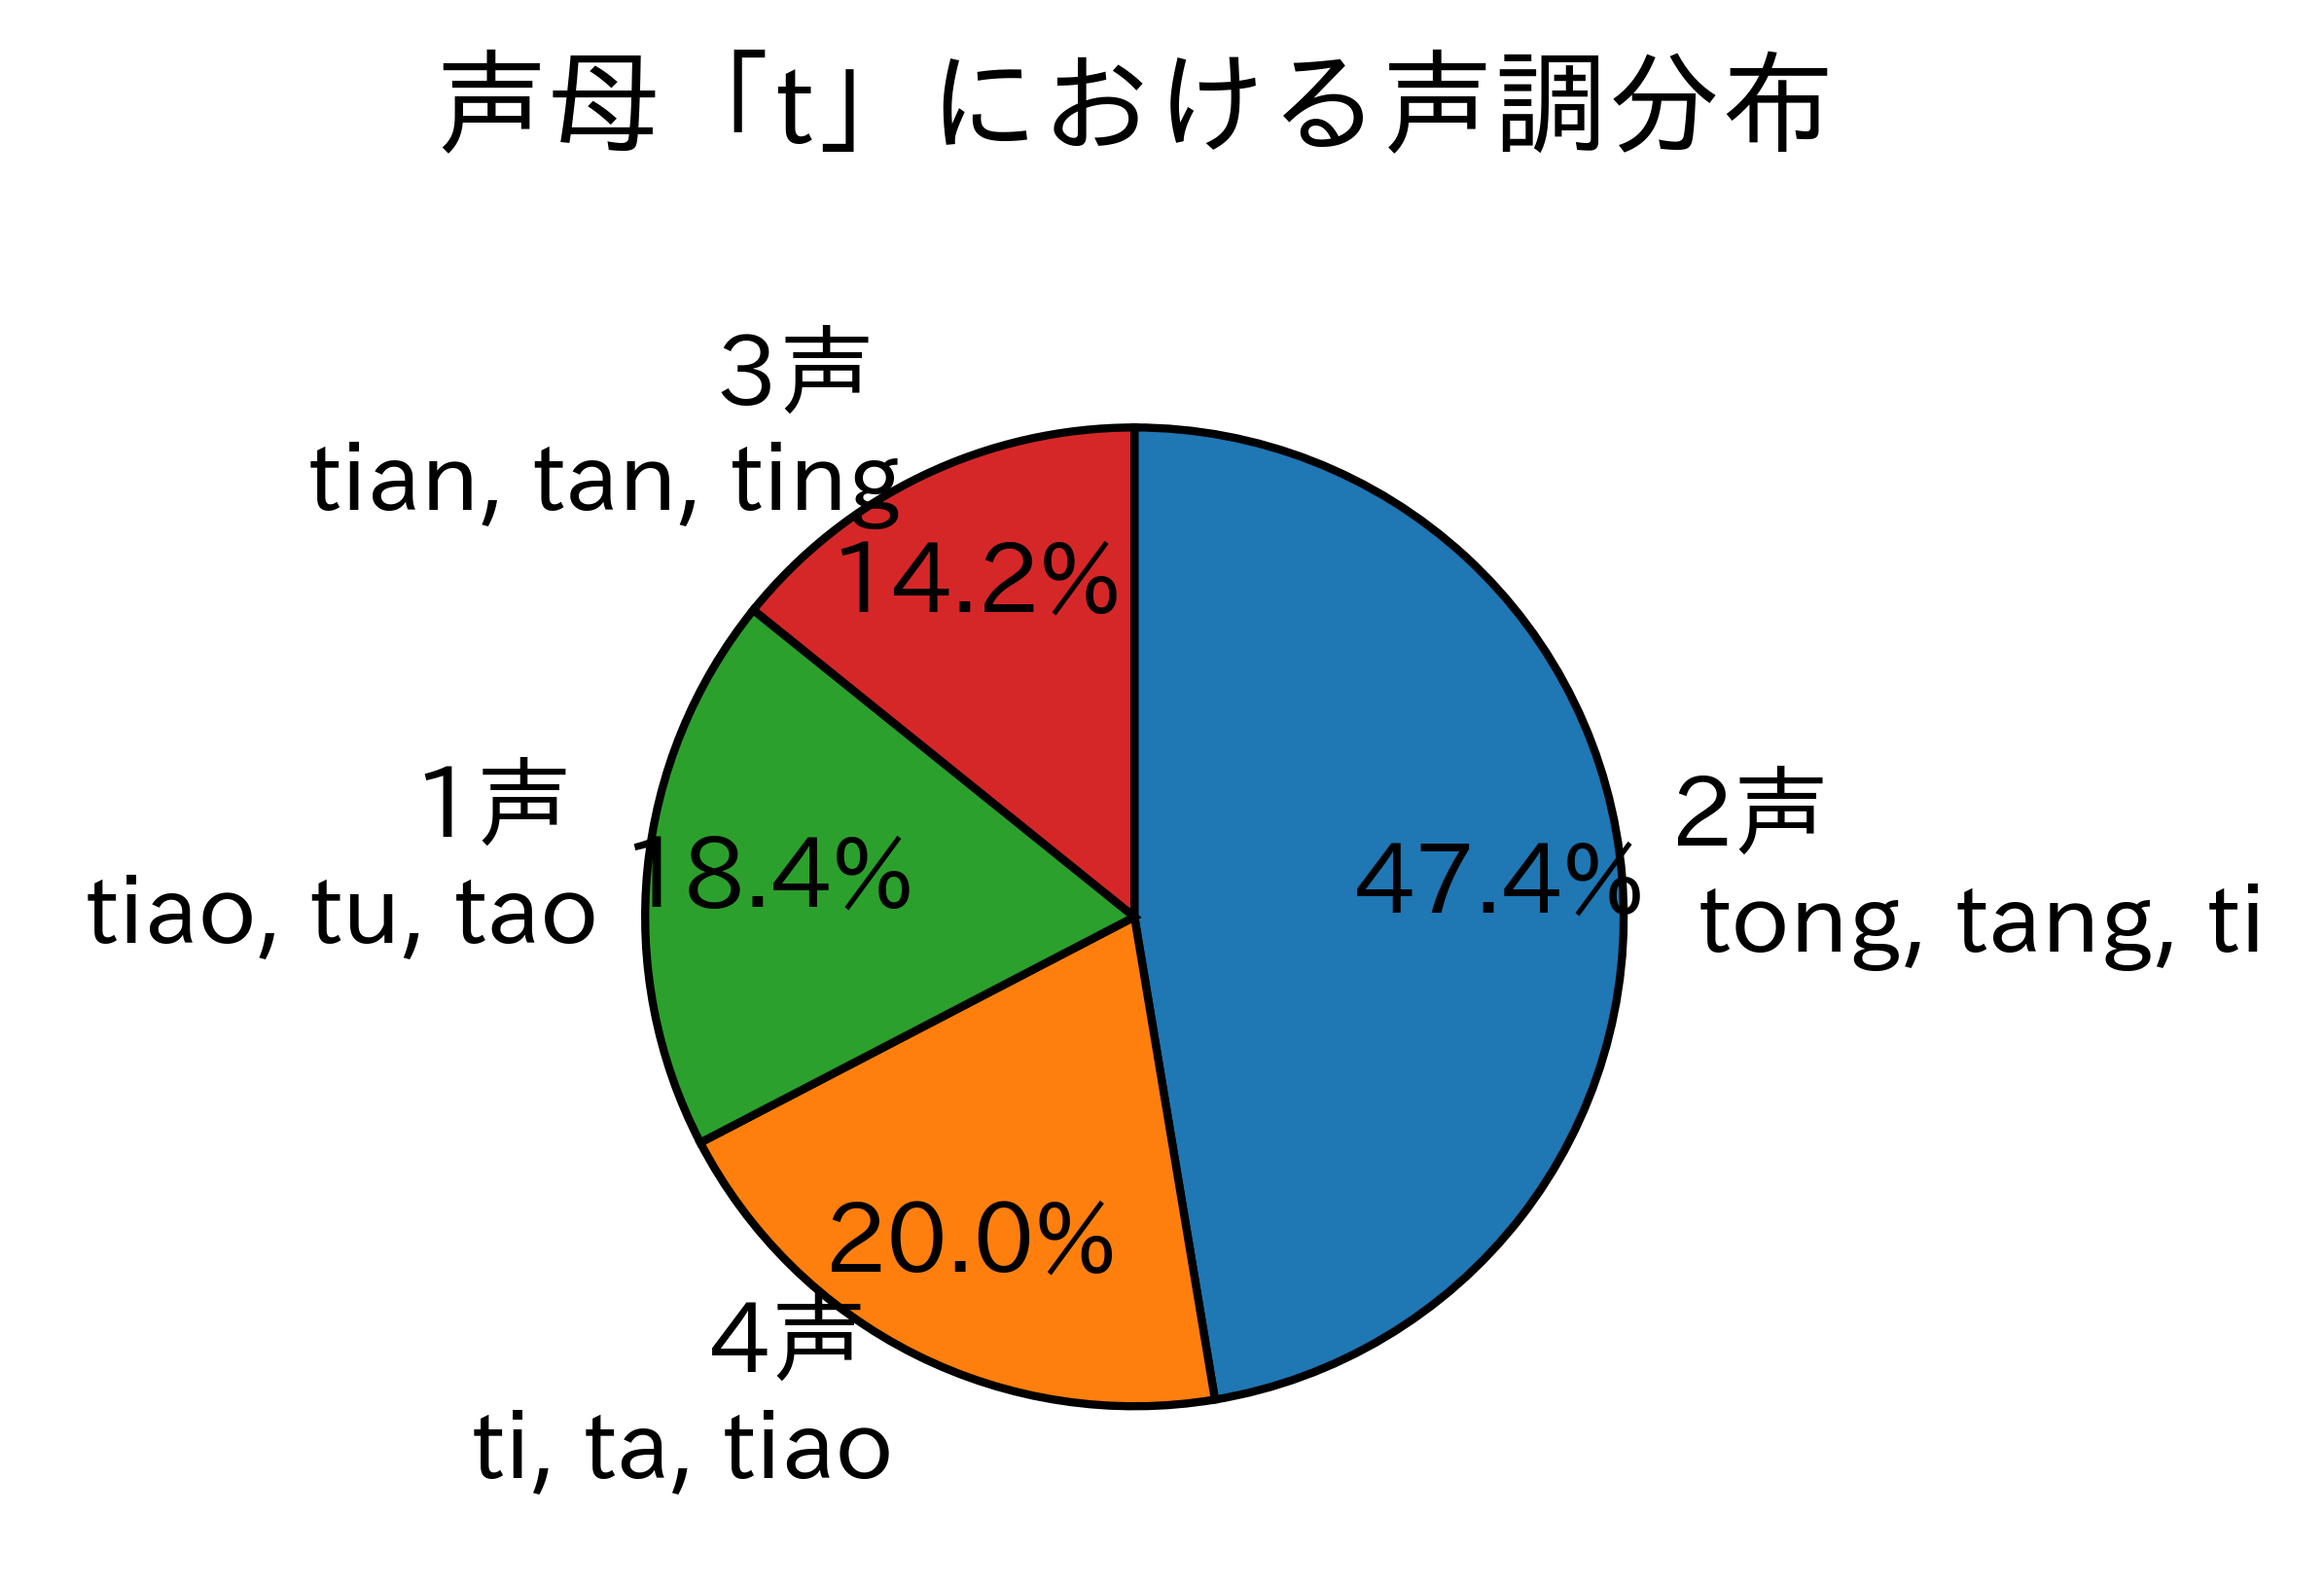

In [93]:
import matplotlib.pyplot as plt
import japanize_matplotlib
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
})

tone_labels = {
    1: f"1声 \n {examples[1]}",
    2: f"2声 \n {examples[2]}",
    3: f"3声 \n {examples[3]}",
    4: f"4声 \n {examples[4]}",
    5: "軽声 }",
}

fig, ax = plt.subplots(figsize=(4, 4), dpi=600)

wedges, texts, autotexts = ax.pie(
    tone_counts.values,
    labels=[tone_labels[x] for x in tone_counts.index],
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    pctdistance=0.75,
    wedgeprops={
        "linewidth": 1,
        "edgecolor": "black"
    }
)

ax.set_title(
    f"声母「{test_consonants}」における声調分布",
    pad=20
)

plt.tight_layout()
plt.show()

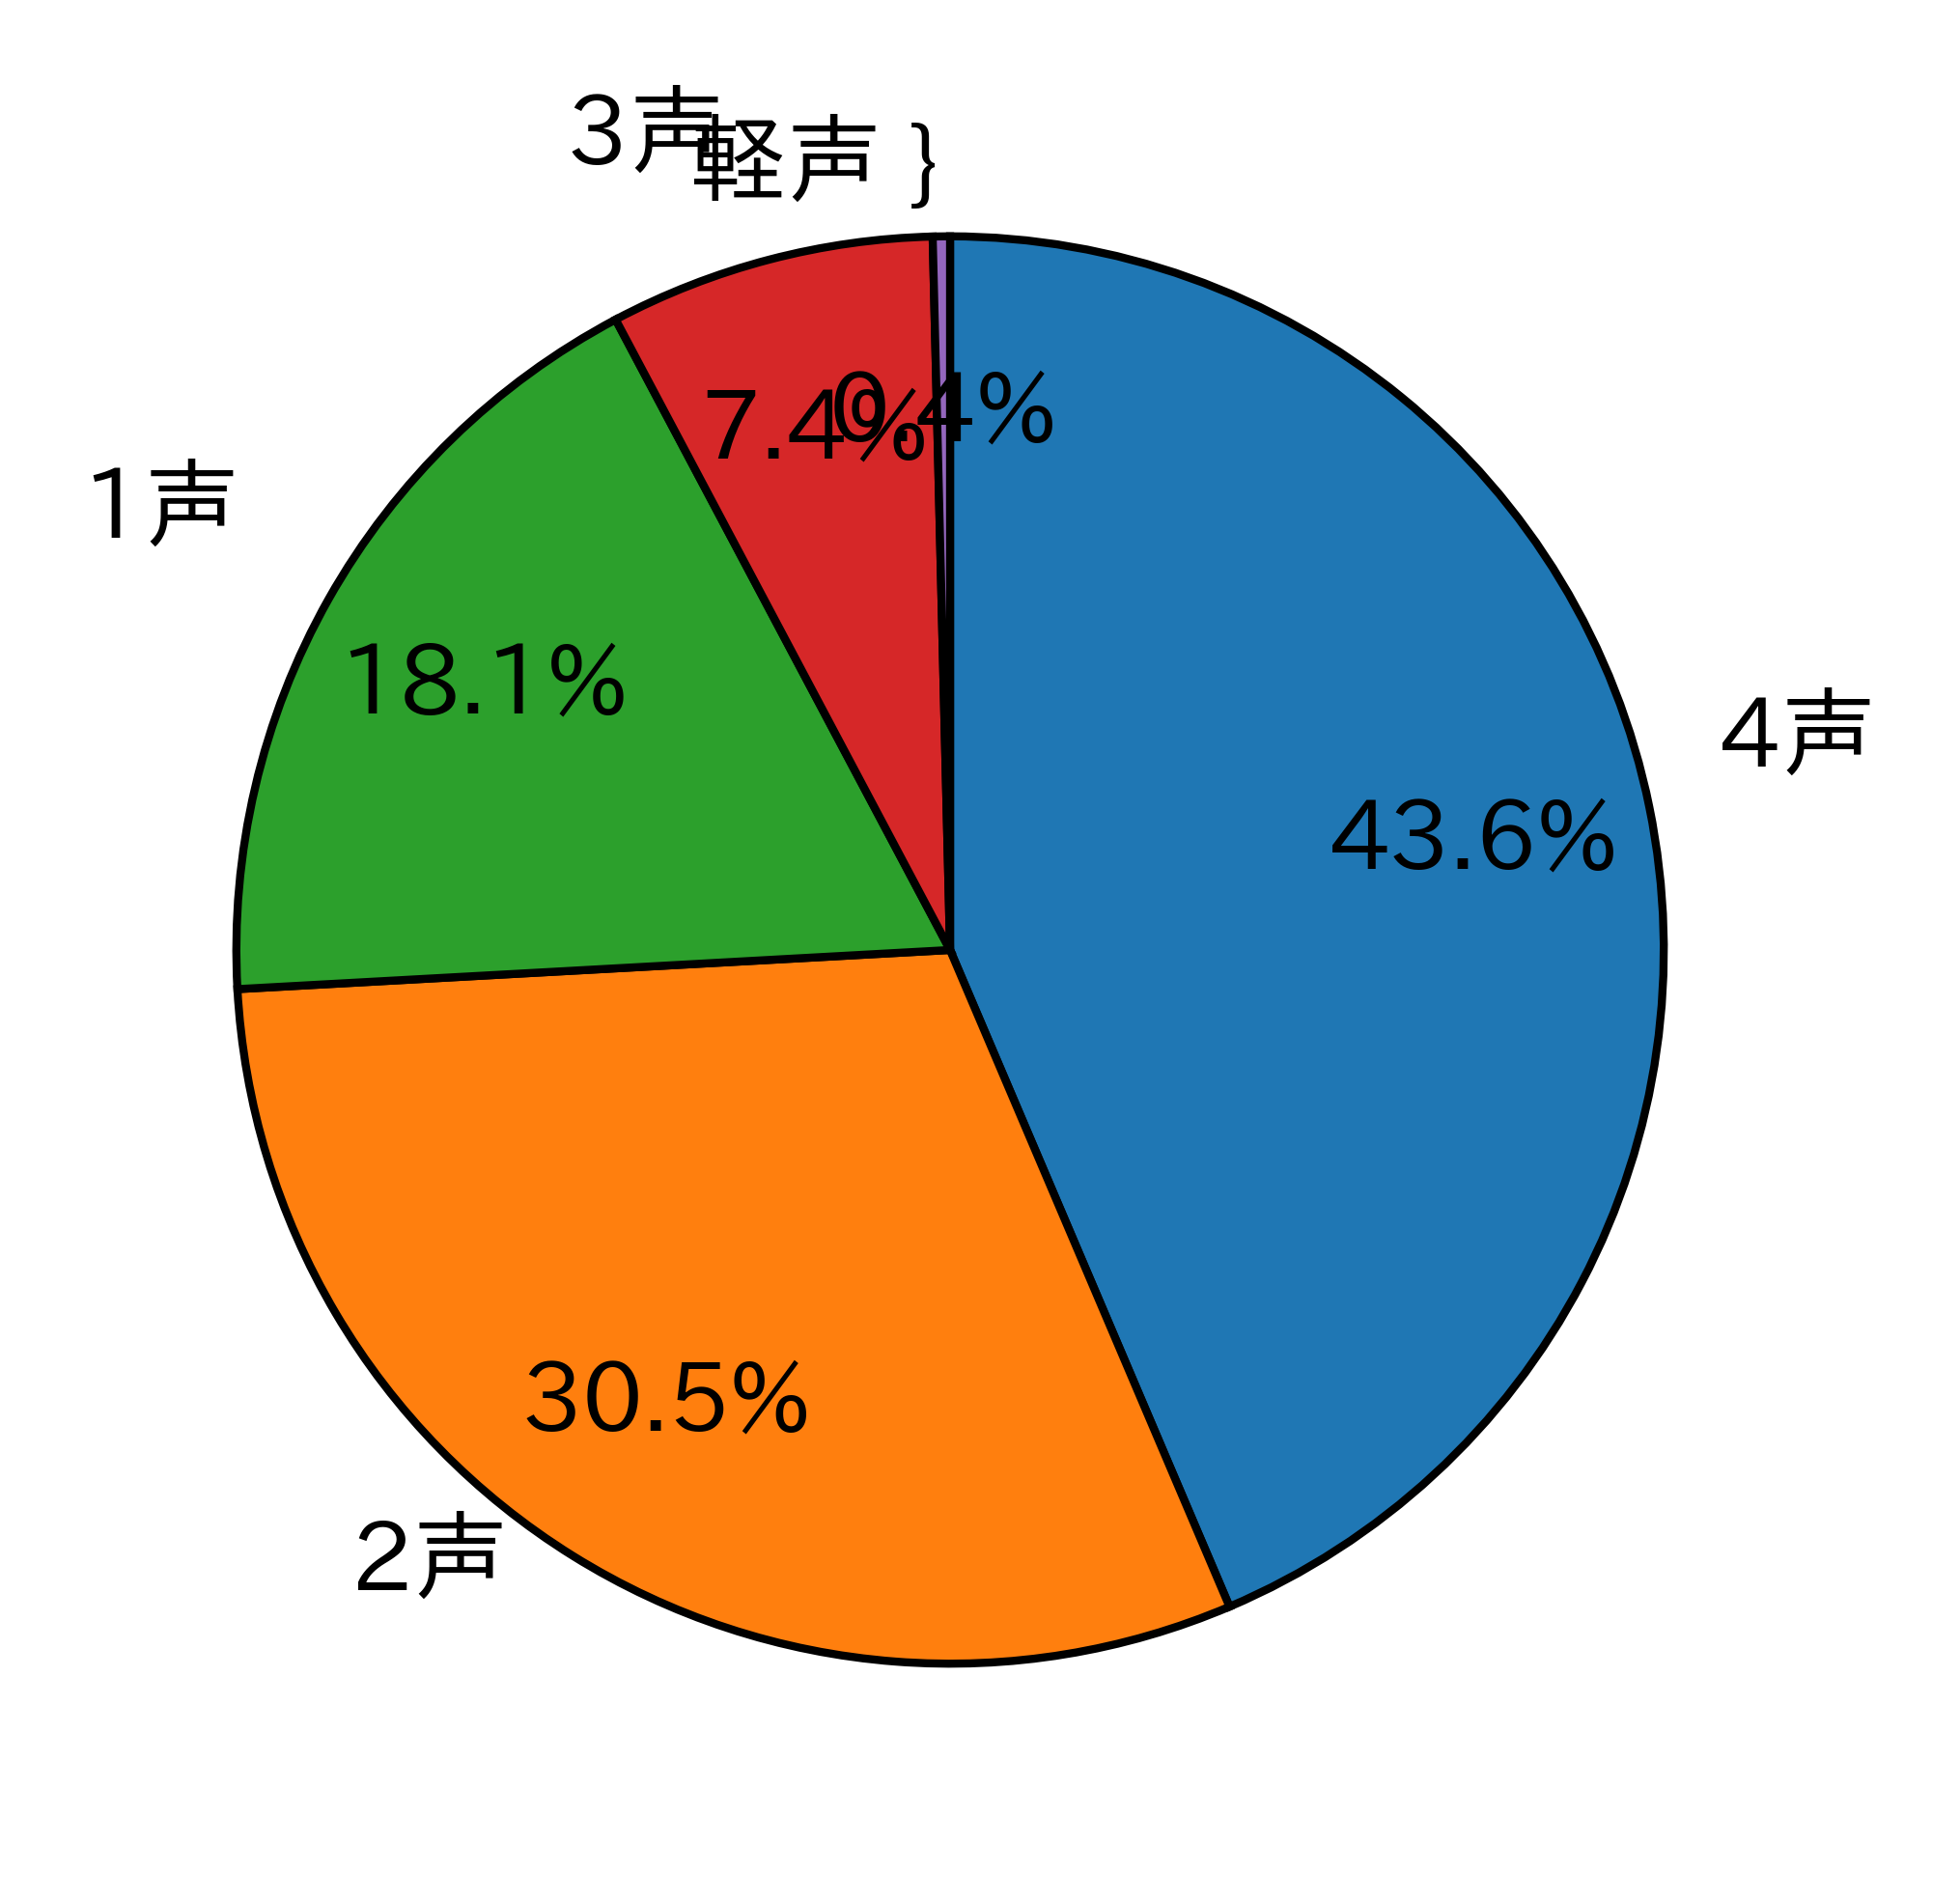

In [94]:
_df = df[df["middle_tone2"] == 4]

tone_counts = (
    _df["tone"]
    .value_counts()
)

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
})

tone_labels = {
    1: f"1声 \n ",
    2: f"2声 \n",
    3: f"3声 \n",
    4: f"4声 \n",
    5: "軽声 }",
}

fig, ax = plt.subplots(figsize=(4, 4), dpi=600)

wedges, texts, autotexts = ax.pie(
    tone_counts.values,
    labels=[tone_labels[x] for x in tone_counts.index],
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    pctdistance=0.75,
    wedgeprops={
        "linewidth": 1,
        "edgecolor": "black"
    }
)

/tmp/ipykernel_962/2264418726.py:103: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  left[i] + pct/2,


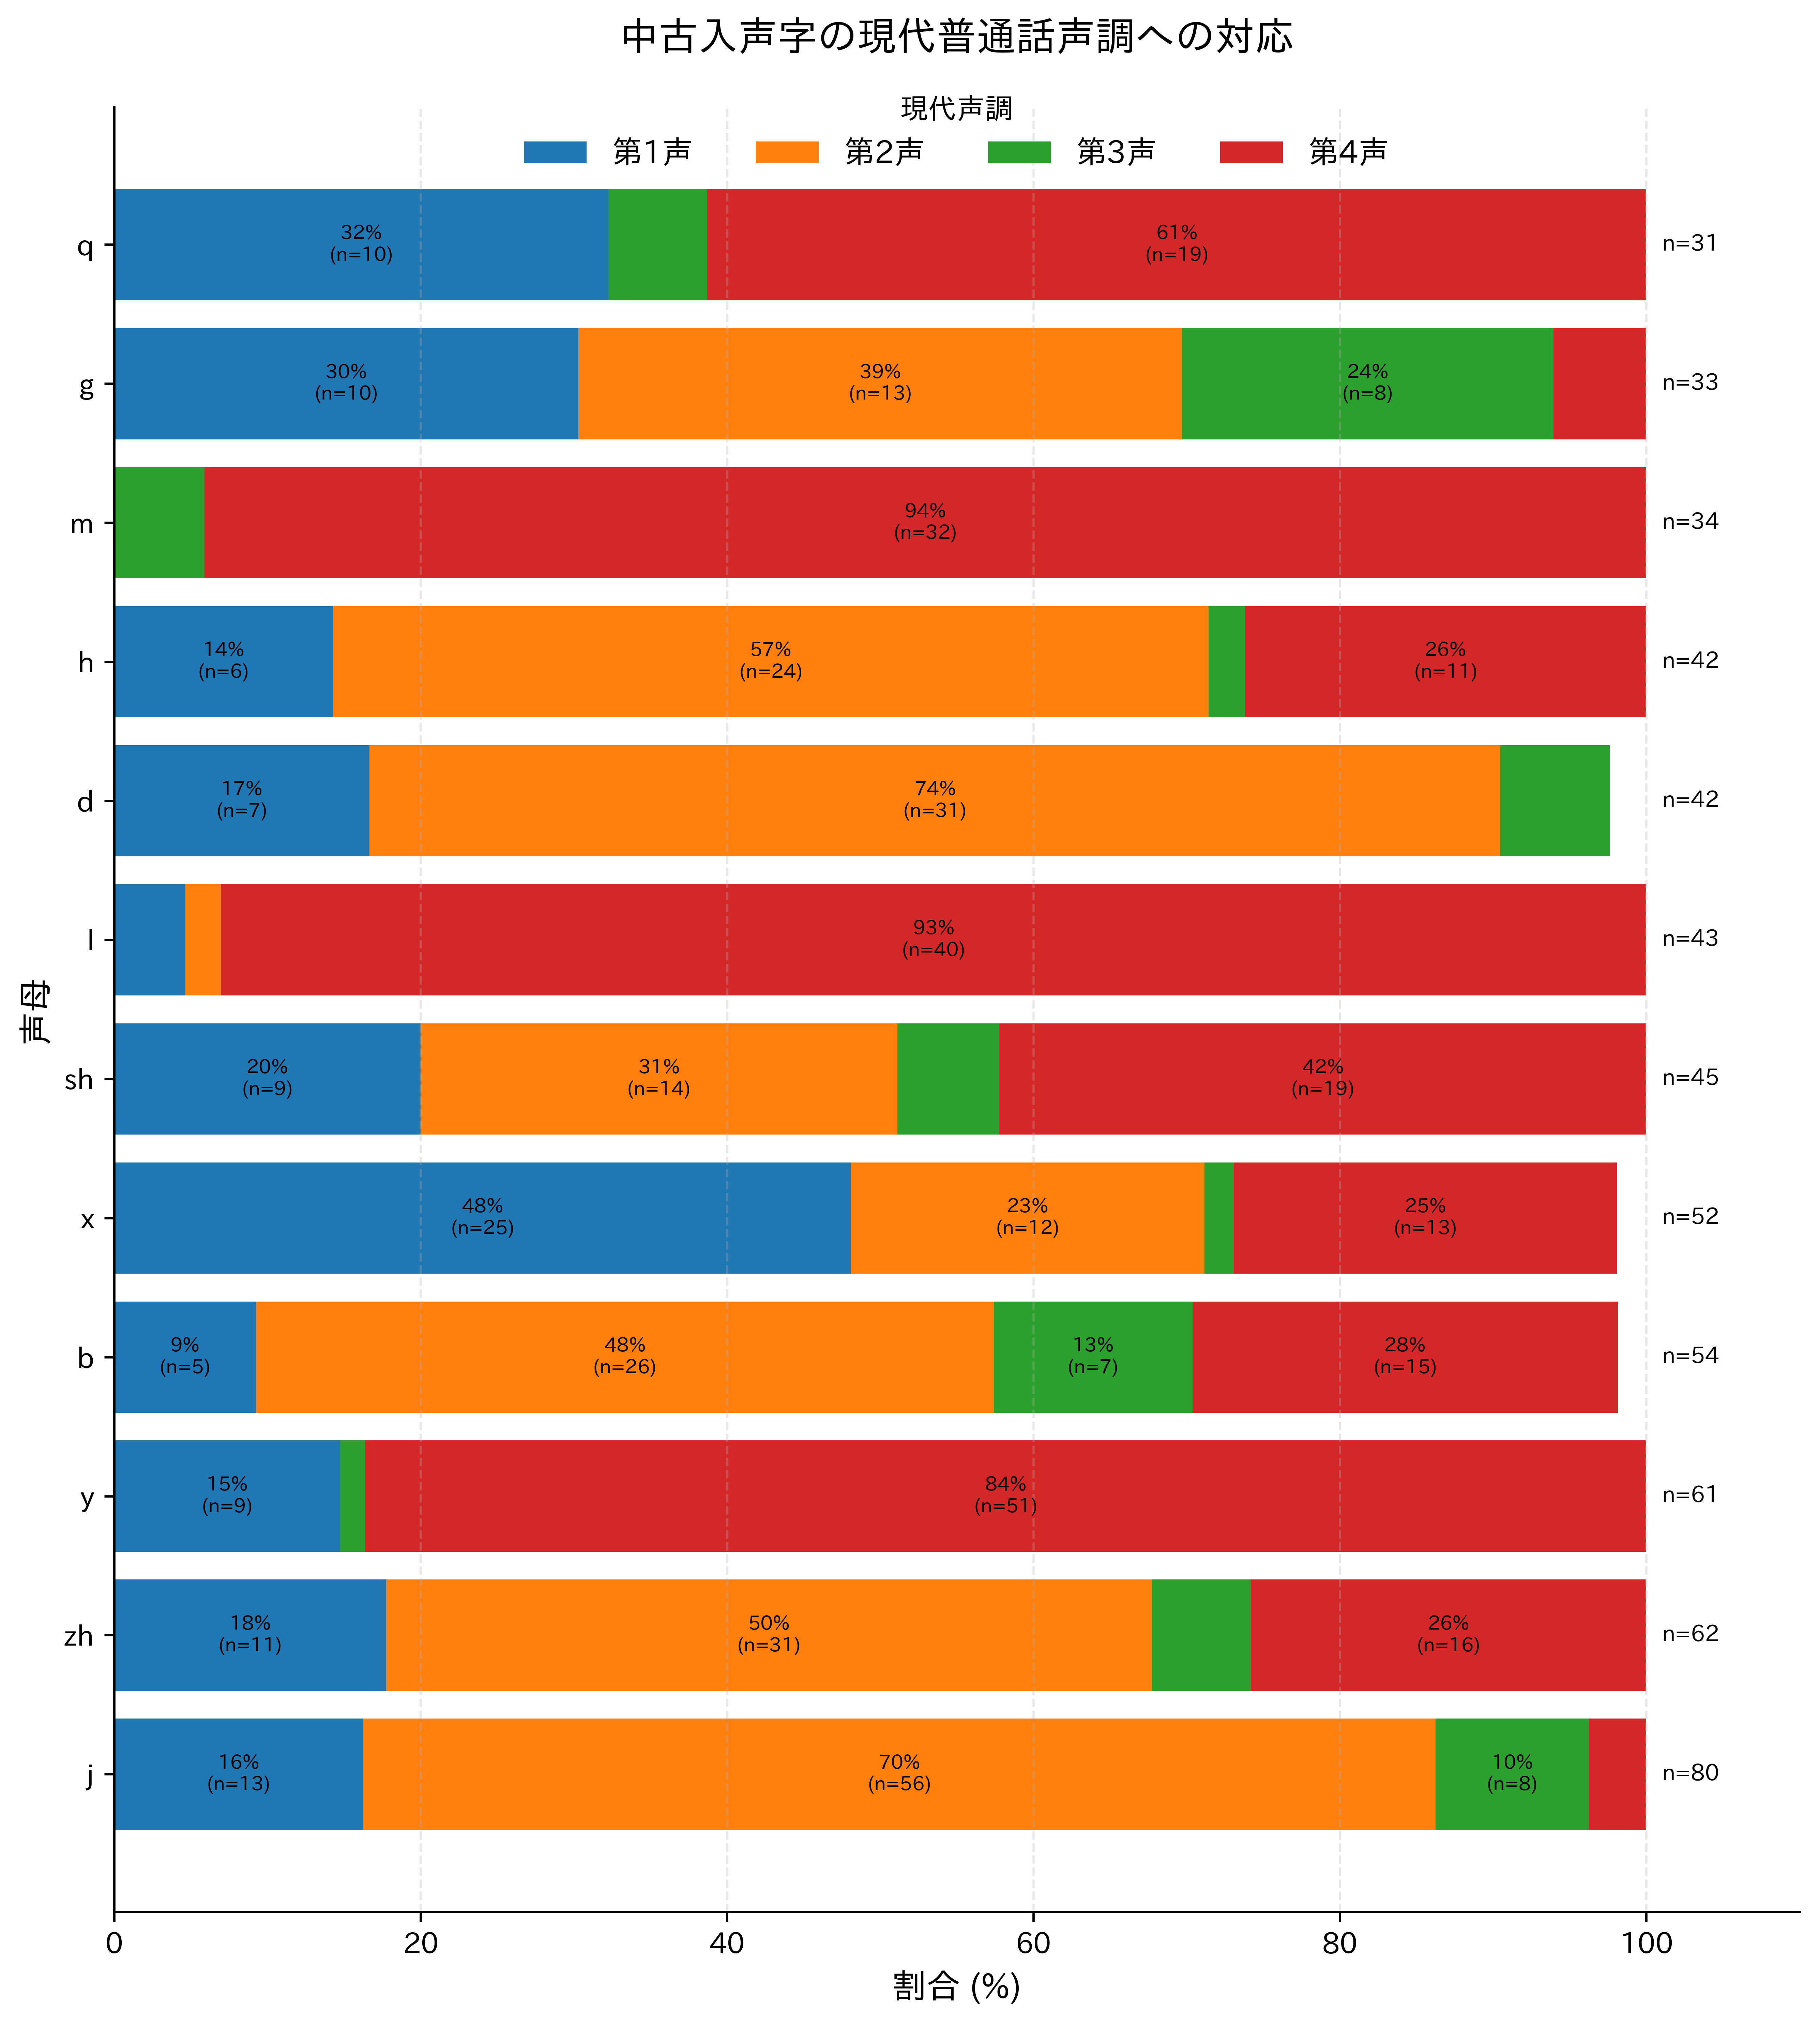

In [95]:
import matplotlib.pyplot as plt
import japanize_matplotlib

# ========================
# 中古入声のみ
# ========================

subset = df[df["middle_tone2"] == 4].copy()

# ========================
# 声母 × 現代声調
# ========================

ct = pd.crosstab(
    subset["consonants"],
    subset["tone"]
)

# 出現数が少なすぎる声母は除外
MIN_COUNT = 30

ct = ct.loc[
    ct.sum(axis=1) >= MIN_COUNT
]

# 総字数
totals = ct.sum(axis=1)

# 100%化
ct_pct = ct.div(
    totals,
    axis=0
) * 100

# 出現数順
order = totals.sort_values(
    ascending=False
).index

ct = ct.loc[order]
ct_pct = ct_pct.loc[order]
totals = totals.loc[order]

# 声調列を揃える
for tone in [1, 2, 3, 4]:

    if tone not in ct.columns:
        ct[tone] = 0
        ct_pct[tone] = 0

ct = ct[[1,2,3,4]]
ct_pct = ct_pct[[1,2,3,4]]

# ========================
# フォント
# ========================

plt.rcParams.update({
    "font.size": 10
})

# ========================
# 描画
# ========================

fig, ax = plt.subplots(
    figsize=(9, 10),
    dpi=600
)

left = np.zeros(len(ct_pct))

tone_labels = {
    1: "第1声",
    2: "第2声",
    3: "第3声",
    4: "第4声"
}

for tone in [1,2,3,4]:

    percentages = ct_pct[tone]
    counts = ct[tone]

    bars = ax.barh(
        ct_pct.index,
        percentages,
        left=left,
        label=tone_labels[tone]
    )

    # --------------------
    # バー内部に表示
    # --------------------

    for i, (pct, cnt) in enumerate(
        zip(percentages, counts)
    ):

        if pct >= 8:

            ax.text(
                left[i] + pct/2,
                i,
                f"{pct:.0f}%\n(n={cnt})",
                ha="center",
                va="center",
                fontsize=7
            )

    left += percentages

# ========================
# 総字数表示
# ========================

for i, total in enumerate(totals):

    ax.text(
        101,
        i,
        f"n={total}",
        va="center",
        fontsize=8
    )

# ========================
# 体裁
# ========================

ax.set_xlim(0, 110)

ax.set_xlabel("割合 (%)")
ax.set_ylabel("声母")

ax.set_title(
    "中古入声字の現代普通話声調への対応",
    fontsize=14,
    pad=20
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="現代声調",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.95),
    loc="lower center"
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

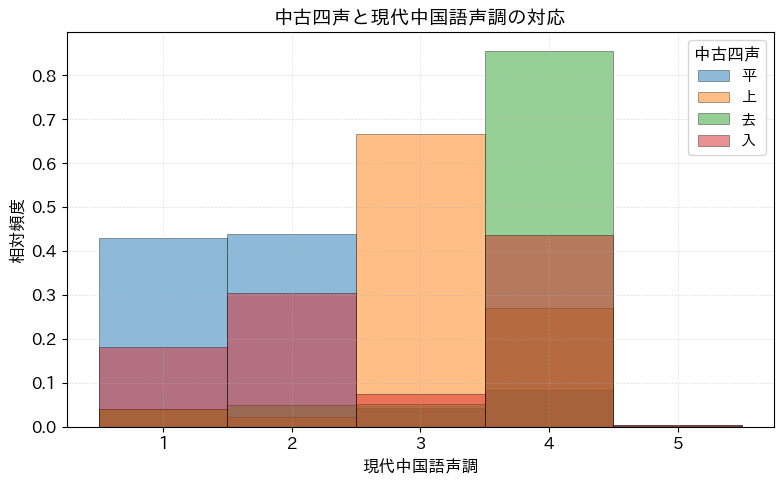

In [96]:
import japanize_matplotlib
plt.rcParams.update({

    "font.size": 12,
    "axes.unicode_minus": False,
})

fig, ax = plt.subplots(figsize=(8, 5))

# 共通ビン
bins = np.arange(df["tone"].min()-0.5,
                 df["tone"].max()+1.5,
                 1)

tones = ["平", "上", "去", "入"]

for tone in tones:
    data = df.loc[df["middle_tone"] == tone, "tone"]

    ax.hist(
        data,
        bins=bins,
        density=True,
        alpha=0.5,
        edgecolor="black",
        linewidth=0.5,
        label=tone
    )

ax.set_xlabel("現代中国語声調")
ax.set_ylabel("相対頻度")
ax.set_title("中古四声と現代中国語声調の対応")
ax.legend(title="中古四声")

ax.grid(
    True,
    linestyle="--",
    linewidth=0.5,
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    "tone_histogram.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [104]:
df.to_csv("chinese_data.csv")

In [103]:
df[(df["middle_tone"] == "上")]

,漢字,ピンイン,频率,累计频率(%),korean,音読み,consonant_jp,vowel_jp,rusheng_jp,consonants,vowel,tone,middle_pronounce,middle_tone,middle_tone2
2,了,le,1380375,7.187538,LYO,リョウ,r,you,False,l,e,5,來蕭四開,上,2
3,是,shì,1327443,8.708969,SI,ゼ,z,e,False,sh,i,4,常支三開,上,2
6,我,wǒ,1087588,11.428463,A,ガ,g,a,False,w,o,3,疑歌一開,上,2
8,在,zài,893208,13.589364,CAY,ザイ,z,ai,False,z,ai,4,從咍一開,上,2
10,有,yǒu,805014,15.527509,YU,ユウ,y,uu,False,y,ou,3,云尤三開,上,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5094,諂,chǎn,1,99.999952,CHEM,テン,t,en,False,ch,an,3,徹鹽三開,上,2
5095,買,mǎi,1,99.999954,MAY,バイ,b,ai,False,m,ai,3,明佳二開,上,2
5098,賄,huì,1,99.999956,HOY,ワイ,w,ai,False,h,ui,4,曉灰一合,上,2
5105,釦,kòu,1,99.999970,KWU,コウ,k,ou,False,k,ou,4,溪侯一開,上,2


In [102]:
df[(df["middle_tone"] == "平")&(df["tone"] == 1)]

,漢字,ピンイン,频率,累计频率(%),korean,音読み,consonant_jp,vowel_jp,rusheng_jp,consonants,vowel,tone,middle_pronounce,middle_tone,middle_tone2
7,他,tā,992169,12.565625,THA,タ,t,a,False,t,a,1,透歌一開,平,1
26,中,zhōng,368320,25.898334,CWUNG,チュウ,c,huu,False,zh,ong,1,知東三開,平,1
40,之,zhī,290083,31.632946,CI,シ,s,hi,False,zh,i,1,章之三開,平,1
48,生,shēng,264009,34.161689,SAYNG,セイ,s,ei,False,sh,eng,1,生庚二開,平,1
49,天,tiān,260519,34.460279,CHEN,テン,t,en,False,t,ian,1,透先四開,平,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5100,趨,qū,1,99.999960,CHWU,スウ,s,uu,False,q,u,1,清虞三合,平,1
5101,趨,qū,1,99.999960,CHOK,スウ,s,uu,False,q,u,1,清虞三合,平,1
5106,銷,xiāo,1,99.999972,SO,ショウ,s,hou,False,x,iao,1,心宵三開,平,1
5107,鏢,biāo,1,99.999975,PHYO,ヒョウ,h,you,False,b,iao,1,滂宵三開,平,1


### 子音清濁分類

In [105]:
import re

initials = [
    "幫","滂","並","明",
    "端","透","定","泥",
    "知","徹","澄","孃",
    "精","清","從","心","邪",
    "莊","初","崇","生","俟",
    "章","昌","常","書","船","日",
    "見","溪","群","疑",
    "影","曉","匣","云",
    "以","來"
]

def get_middle_initial(x):
    for ini in initials:
        if x.startswith(ini):
            return ini
    return None

df["middle_initial"] = df["middle_pronounce"].apply(get_middle_initial)

In [106]:
voicing_map = {}

for x in [
    "幫","端","知","精","莊","章",
    "見","影","曉","心","生","書"
]:
    voicing_map[x] = "全清"

for x in [
    "滂","透","徹","清","初","昌",
    "溪"
]:
    voicing_map[x] = "次清"

for x in [
    "並","定","澄","從","崇","常",
    "群","匣","邪","船","俟"
]:
    voicing_map[x] = "全濁"

for x in [
    "明","泥","孃","疑",
    "日","來","云","以"
]:
    voicing_map[x] = "次濁"

df["voice_class"] = (
    df["middle_initial"]
    .map(voicing_map)
)

In [107]:
def jp_voicing(cons):
    if cons in ["k","s","t","h"]:
        return "清"

    if cons in ["g","z","d","b"]:
        return "濁"

    if cons in ["p"]:
        return "半濁"

    if cons in ["m","n","r","w","y"]:
        return "鼻音・流音"

    return "その他"

df["jp_voicing"] = (
    df["consonant_jp"]
    .apply(jp_voicing)
)

In [109]:
retroflex = {
    "zh",
    "ch",
    "sh",
    "r"
}

df["retroflex"] = (
    df["consonants"]
    .isin(retroflex)
)
df

,漢字,ピンイン,频率,累计频率(%),korean,音読み,consonant_jp,vowel_jp,rusheng_jp,consonants,vowel,tone,middle_pronounce,middle_tone,middle_tone2,middle_initial,voice_class,jp_voicing,retroflex
0,的,de,3244537,3.718684,CEK,テキ,t,eki,True,d,e,5,端青四開,入,4,端,全清,清,False
2,了,le,1380375,7.187538,LYO,リョウ,r,you,False,l,e,5,來蕭四開,上,2,來,次濁,鼻音・流音,False
3,是,shì,1327443,8.708969,SI,ゼ,z,e,False,sh,i,4,常支三開,上,2,常,全濁,濁,True
4,不,bù,1285160,10.181939,PWU,フ,f,u,False,b,u,4,幫尤三開,平,1,幫,全清,その他,False
5,不,bù,1285160,10.181939,PWUL,フ,f,u,False,b,u,4,幫尤三開,平,1,幫,全清,その他,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5115,飲,yǐn,1,99.999987,UM,イン,,in,False,y,in,3,影侵三開,上,2,影,全清,その他,False
5116,驟,zhòu,1,99.999992,CHWI,シュウ,s,huu,False,zh,ou,4,崇尤三開,去,3,崇,全濁,清,True
5117,髏,lóu,1,99.999993,LWU,ロウ,r,ou,False,l,ou,2,來侯一開,平,1,來,次濁,鼻音・流音,False
5118,鴰,guā,1,99.999997,KWAL,カツ,k,atsu,True,g,ua,1,見桓一合,入,4,見,全清,清,False


(array([417., 317., 435., 147., 160., 224., 148., 145., 132.,  25.]),
 array([ 0. ,  3.2,  6.4,  9.6, 12.8, 16. , 19.2, 22.4, 25.6, 28.8, 32. ]),
 <BarContainer object of 10 artists>)

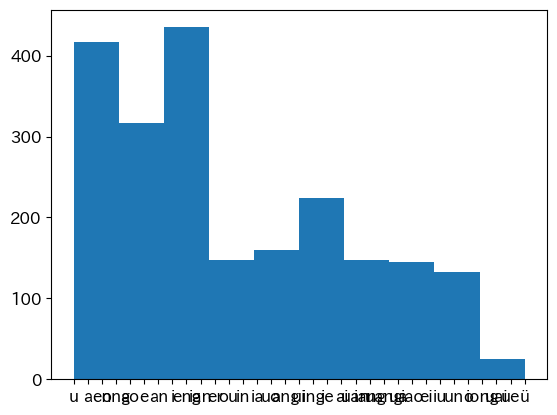

,tone
0,5
2,5
3,4
4,4
5,4
...,...
5115,3
5116,4
5117,2
5118,1


In [117]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from catboost import CatBoostClassifier

# ----------------------
# データ準備
# ----------------------

df = df.copy()

# 使う特徴量
feature_cols = [
    "consonants",     # 現代中国語声母
    "vowel",          # 現代中国語韻母
    # "tone",           # 普通話声調

    "consonant_jp",   # 音読み子音
    "vowel_jp",

    "middle_pronounce",
]

target_col = "middle_tone"

df = df.dropna(
    subset=feature_cols + [target_col]
)

X = df[feature_cols]
y = df[target_col]

# ----------------------
# train / test
# ----------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ----------------------
# CatBoost
# ----------------------

cat_features = list(range(len(feature_cols)))

model = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.03,
    loss_function="MultiClass",
    eval_metric="MultiClass",
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test)
)

# ----------------------
# 精度確認
# ----------------------

pred = model.predict(X_test)

print(
    classification_report(
        y_test,
        pred
    )
)

0:	learn: 1.3631391	test: 1.3626696	best: 1.3626696 (0)	total: 80.8ms	remaining: 1m 20s
100:	learn: 0.8711746	test: 0.8681613	best: 0.8681613 (100)	total: 4.47s	remaining: 39.8s
200:	learn: 0.7954661	test: 0.8208356	best: 0.8208356 (200)	total: 7.38s	remaining: 29.3s


In [119]:
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.get_feature_importance()
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print(importance)

            feature  importance
6      middle_tone2   84.796137
2              tone    7.995658
0        consonants    3.858036
3      consonant_jp    2.122422
1             vowel    0.675683
4          vowel_jp    0.552063
5  middle_pronounce    0.000000
